# Translational motion planning

The shortest collision-free motion of a convex polygonal robot among polygonal
obstacles, by the classical reduction of Lozano-Pérez and Wesley (*An algorithm
for planning collision-free paths among polyhedral obstacles*, CACM 22(10),
1979): under pure translation a configuration is a point, the free configuration
space is a polygonal region, and a shortest path in it is a shortest path in a
finite graph.

The three steps are an erosion, a visibility graph and a shortest-path search,
and every one of them is a single call here. What the notebook adds over
[`examples/example_motion.py`](../example_motion.py) is the intermediate state:
one figure per stage, and the two certificates checked rather than asserted.

In [1]:
import pypgl as pgl

pgl.REPR_SVG_SIZE = 300


def figure(*layers, size=(760, 500)):
    """Draw (shape, stroke, fill) layers onto one canvas, in order."""
    canvas = pgl.Canvas().size(*size).margin(14).strokeWidth(1.5)
    for shape, stroke, fill in layers:
        canvas.stroke(stroke).fill(fill).draw(shape)
    return canvas

## Workspace

A chamfered room with three staggered obstacles, as a `PolygonWithHoles`.
Structural validity — a simple outer boundary and pairwise interior-disjoint
holes inside it — is a precondition of the operations below rather than an
invariant of the type, so it is checked explicitly.

28 vertices, 3 holes, area 13237/2


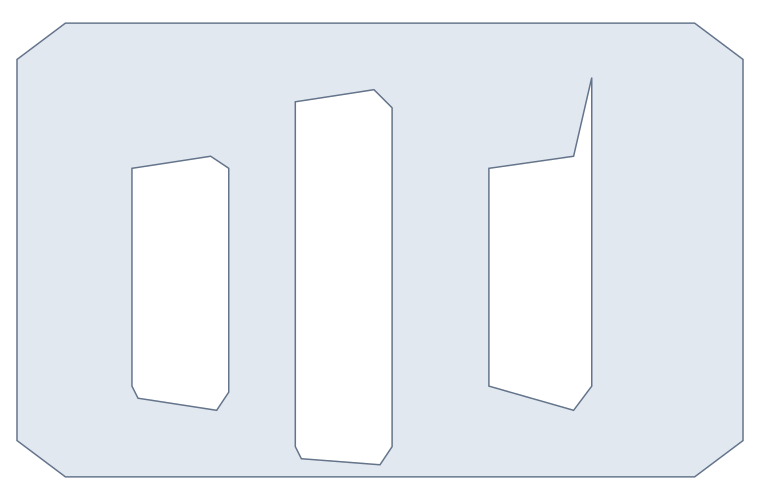

In [2]:
outer = pgl.Polygon([0,6, 8,0, 112,0, 120,6, 120,69, 112,75, 8,75, 0,69])
holes = [pgl.Polygon([20,13, 33,11, 35,14, 35,51, 32,53, 19,51, 19,15]),
         pgl.Polygon([47,3, 60,2, 62,5, 62,61, 59,64, 46,62, 46,5]),
         pgl.Polygon([92,11, 95,15, 95,66, 92,53, 78,51, 78,15])]

room = pgl.PolygonWithHoles(outer, holes)
assert room.isValid()

print(f"{room.vertexCount()} vertices, {room.holeCount()} holes, area {room.area()}")

figure((room, "#64748b", "#e2e8f0"))

## The robot, and its configuration space

The robot is a hexagon given relative to its reference point, so the placement at
$x$ is the translate $R \\oplus x$. The admissible configurations are therefore

$$\\mathcal{F} = \\{x : R \\oplus x \\subseteq W\\} = W \\ominus R,$$

the Minkowski erosion — the reduction that turns a moving region into a moving
point. Note the erosion is taken with the robot as given, not reflected: the
reflection appears in the equivalent formulation that grows each obstacle by
$-R$.

An erosion can disconnect a region, so it returns a `PolygonSet`; here the free
space stays in one piece.

free space: 43 vertices, 2 holes


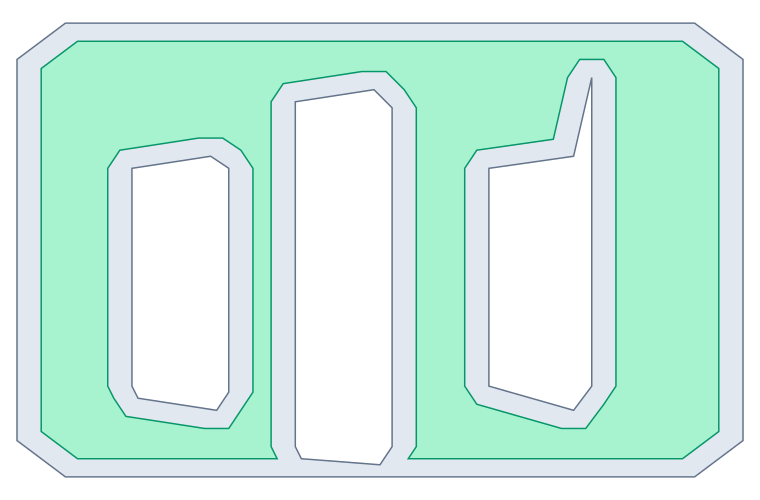

In [3]:
robot = pgl.Convex([-4,0, -2,-3, 2,-3, 4,0, 2,3, -2,3])

components = room.minkowskiErosion(robot)
assert components.componentCount() == 1
free = components.component(0)

print(f"free space: {free.vertexCount()} vertices, {free.holeCount()} holes")

figure((room, "#64748b", "#e2e8f0"),
       (free, "#059669", "#a7f3d0"))

The hole count drops from three to two. The middle obstacle spans $y \\in [2, 64]$
and the robot reaches three units below its reference point, so the obstacle's
image in configuration space meets the bottom wall: it ceases to be an island,
and no route passes beneath it. The clearance is real and the failure is
decided, not estimated —

In [4]:
below = pgl.Point(54, 1)

print("in the workspace: ", room.contains(below))
print("in the free space:", free.contains(below))
print("robot placed there is inside the room:", room.contains(robot + below))

in the workspace:  True
in the free space: False
robot placed there is inside the room: False


## The reduced visibility graph

A shortest path in a polygonal domain is a polyline whose interior vertices are
reflex vertices of the domain, so it suffices to search a graph on the free
space's vertices. The *reduced* graph keeps only the edges along which a taut
path can bend — tangent to the boundary at both endpoints — which is a
substantially smaller graph than the complete visibility graph and, as checked
below, loses no shortest path.

reduced:  43 vertices, 50 edges
complete: 43 vertices, 155 edges


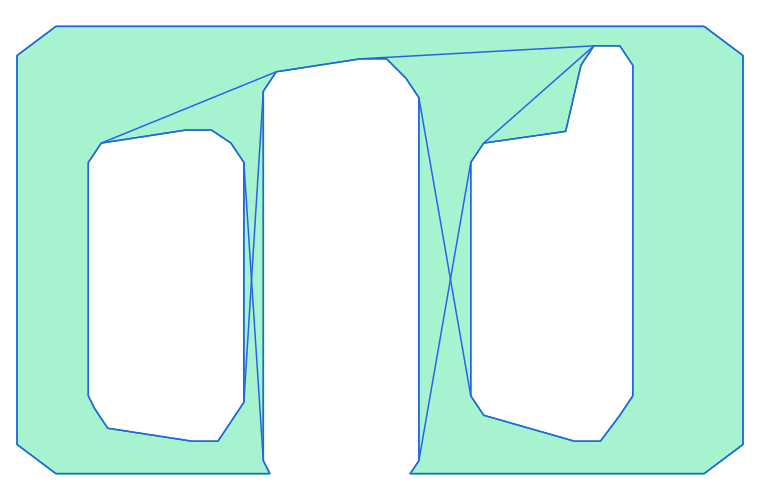

In [5]:
graph = free.reducedVisibilityGraph()
complete = free.visibilityGraph()

print(f"reduced:  {graph.vertexCount()} vertices, {graph.edgeCount()} edges")
print(f"complete: {complete.vertexCount()} vertices, {complete.edgeCount()} edges")

figure((free,  "#059669", "#a7f3d0"),
       ([pgl.Segment(u, v) for u, v in graph.edges()], "#2563eb", "none"))

## Endpoints

The source and target are interior points, not vertices of the free space, so the
reduced graph contains neither. Each is inserted and joined to every free-space
vertex it sees; inserting the vertex first also covers an endpoint that sees no
corner at all. A clear line of sight between the two endpoints is itself a legal
path with no graph vertex in its interior, so it needs an edge of its own.

In [6]:
source, target = pgl.Point(8, 8), pgl.Point(110, 10)
assert free.contains(source) and free.contains(target)

for endpoint in (source, target):
    graph.addVertex(endpoint)
    for vertex in free.visibleVertices(endpoint):
        graph.addEdge(endpoint, vertex)

if free.contains(pgl.Segment(source, target)):
    graph.addEdge(source, target)

print(f"{graph.vertexCount()} vertices, {graph.edgeCount()} edges after attaching")

45 vertices, 71 edges after attaching


## Search

`shortestPath` takes the edge weight as a Python callable, and a fifth argument
makes it A\\*: a lower bound on the remaining cost. Straight-line distance is
admissible and consistent here, being the length of the unobstructed motion.

The weights leave $\\mathbb{Q}$ — a Euclidean length is a square root — and this
is the one place in the pipeline that is not exact. The combinatorics stay
exact: which vertices are mutually visible was decided over $\\mathbb{Q}$, and
only the comparison of two path lengths is done in floating point.

In [7]:
distance = lambda a, b: a.distance(b)

path = graph.shortestPath(source, target, distance, distance)
assert path

def length(p):
    return sum(distance(a, b) for a, b in zip(p, p[1:]))

print(f"{len(path)} waypoints, length {length(path):.6f}")
print(" ".join(str(p) for p in path))

13 waypoints, length 186.308248
(8,8) (15,51) (17,54) (44,65) (57,67) (61,67) (64,64) (66,61) (74,15) (76,12) (90,8) (94,8) (110,10)


Two claims are worth checking rather than believing. Dijkstra (the four-argument
overload) must agree with A\\*, and the reduced graph must agree with the complete
one — the reduction is a claim about shortest paths, not a heuristic.

In [8]:
for endpoint in (source, target):
    complete.addVertex(endpoint)
    for vertex in free.visibleVertices(endpoint):
        complete.addEdge(endpoint, vertex)
if free.contains(pgl.Segment(source, target)):
    complete.addEdge(source, target)

alternatives = {
    "reduced graph, A*":       path,
    "reduced graph, Dijkstra": graph.shortestPath(source, target, distance),
    "complete graph, A*":      complete.shortestPath(source, target, distance, distance),
}
for name, p in alternatives.items():
    print(f"{name:26} {len(p):2d} waypoints   length {length(p):.9f}")

print("\nedges searched:", graph.edgeCount(), "against", complete.edgeCount())

reduced graph, A*          13 waypoints   length 186.308247642
reduced graph, Dijkstra    13 waypoints   length 186.308247642
complete graph, A*         13 waypoints   length 186.308247642

edges searched: 71 against 176


## Certificates

The path is a polyline in configuration space. Two exact containments say that
the corresponding motion is collision-free, and the second is the stronger one:
the region swept by the robot along the whole path — not merely its footprint at
the waypoints — lies inside the room. Both are decided over $\\mathbb{Q}$.

In [9]:
motion = pgl.Polyline(path)
swept  = motion.minkowskiSum(robot)

print("the path stays in the free space:  ", free.contains(motion))
print("the swept region stays in the room:", room.contains(swept))
print("swept region:", type(swept).__name__, " area", swept.area())

the path stays in the free space:   True
the swept region stays in the room: True
swept region: PolygonWithHoles  area 1394


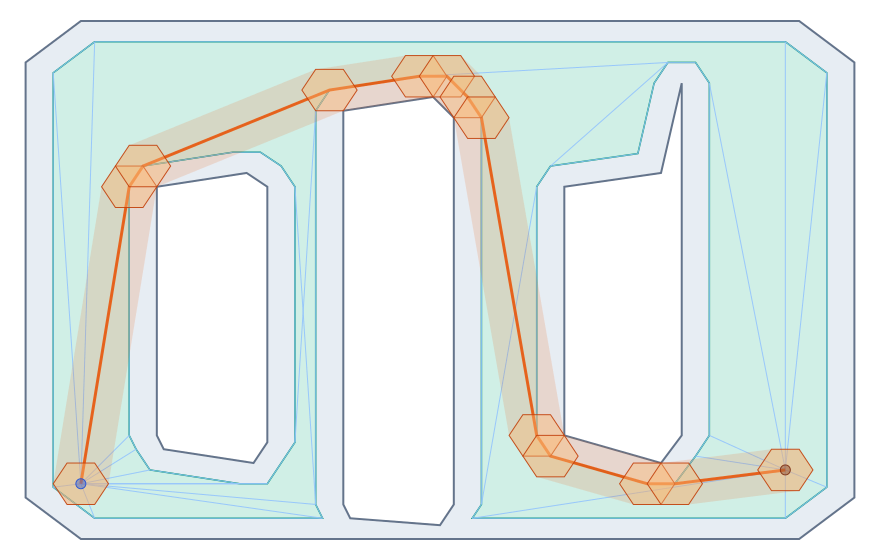

In [10]:
canvas = pgl.Canvas().size(880, 560).margin(16)

canvas.stroke("#64748b").strokeWidth("2px").fill("#e2e8f0").fillOpacity("0.8")
canvas.draw(room)

canvas.stroke("#059669").strokeWidth("1.5px").fill("#a7f3d0").fillOpacity("0.35")
canvas.draw(free)

canvas.stroke("#93c5fd").strokeWidth("1px").strokeOpacity("0.9").fill("none")
canvas.draw(pgl.Segment(u, v) for u, v in graph.edges())

canvas.stroke("none").fillOpacity("15%").fill("#ea580c")
canvas.draw(swept)
canvas.stroke("#ea580c").strokeWidth("3px").fill("none")
canvas.draw(motion)

canvas.stroke("#c2410c").strokeWidth("1px").fill("#fdba74").fillOpacity("0.4")
canvas.draw(robot + waypoint for waypoint in path)

canvas.stroke("#1d4ed8").fill("#1d4ed8").pointRadius("5").draw(source)
canvas.stroke("#7c2d12").fill("#7c2d12").pointRadius("5").draw(target)
canvas

The translucent footprints are the robot at each waypoint and the orange band is
the swept region, both inside the room; the blue edges are the graph actually
searched.

## Further

- [`booleans.ipynb`](booleans.ipynb) — the erosion in general: its result types,
  its adjointness to the sum, and why it can disconnect a region.
- [`doc/algorithms.md`](../../doc/algorithms.md) — the visibility family and
  `Graph`, including the weighted searches and what a weight callable may return.
- [`examples/example_motion.py`](../example_motion.py),
  [`examples/example_visibility.py`](../example_visibility.py) — the same
  material as scripts.